In [1]:
library(tidyverse)  # Data wrangling packages.
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load in and prepare data

In [28]:
files <- system(
  "gsutil ls gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_*",
  intern = TRUE
)

files

[1] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ES.csv"                                          
 [2] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ESsens2.csv"                                     
 [3] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_HCAU.csv"                                        
 [4] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_NBD.csv"                                         
 [5] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_SCC.csv"                                         
 [6] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_SDOH.csv"                                        
 [7] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_SDOHsens2.csv"                                   
 [8] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_area_poverty.csv"                                
 [9] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_area_poverty_SES_subset.csv"                     
[10] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_area_poverty_subset.csv"                         
[11] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_assited_income.csv"                              
[12] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_assited_income_SES_subset.csv"                   
[13] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_assited_income_subset.csv"                       
[14] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ddimer_PRS_race__sens2.csv"                      
[15] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ddimer_PRS_sens2.csv"                            
[16] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ddimer_PRS_sens2_female_stratified_.csv"         
[17] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_ddimer_PRS_sens2_male_stratified_.csv"           
[18] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_deprivation_index.csv"                           
[19] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_deprivation_index_SES_subset.csv"                
[20] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_deprivation_index_subset.csv"                    
[21] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_education.csv"                                   
[22] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_education_SES_subset.csv"                        
[23] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_high_school_education.csv"                       
[24] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_high_school_education_SES_subset.csv"            
[25] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_high_school_education_subset.csv"                
[26] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_income_SES_subset.csv"                           
[27] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_median_income.csv"                               
[28] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_median_income_SES_subset.csv"                    
[29] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_median_income_subset.csv"                        
[30] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_no_health_insurance.csv"                         
[31] "gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_no_health_insurance_SES_subset.csv"              
[32] "gs://fc-secure-23df4c45-3a9

In [47]:
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_*", " ."), intern=T)

dfs<-c("SCC", "NBD", "ES", "HCAU", "education", 
      "median_income_subset", "high_school_education_subset", "no_health_insurance_subset",
      "vacant_housing_subset", "deprivation_index_subset")

# Load and combine all files into one dataframe
combined_df <- map_dfr(dfs, function(domain) {
  file_path <- paste0("phewas_results_", domain, ".csv")
  if (file.exists(file_path)) {
    df <- read.csv(file_path) %>%
      mutate(Domain = domain)  # Append domain column
    return(df)
  } else {
    message("File not found: ", file_path)
    return(NULL)  # Skip if file doesn't exist
  }
})

# View combined dataframe
print(nrow(combined_df))
combined_df<-combined_df[combined_df$cases>=100, ]
combined_df<-combined_df[combined_df$converged=="True", ]
combined_df <- combined_df %>%
  group_by(phecode) %>%
  filter(n() == 10) %>%
  ungroup()

combined_df<-combined_df[combined_df$group %in% c("circulatory system", "endocrine/metabolic",
                                              "genitourinary", "neoplasms", "respiratory" ), ]
nrow(combined_df)
p_value_numeric<-.05/nrow(combined_df)
combined_df_sig<-combined_df[combined_df$p_value<p_value_numeric, ]
print(nrow(combined_df_sig))
head(combined_df)

character(0)

[1] 16792


[1] 5130

[1] 1244


phecode,description,groupnum,group,color,cases,control,p_value,beta_ind,conf_int_1,conf_int_2,converged,code_val,neg_p_log_10,Domain
<dbl>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
145.0,Cancer of mouth,2,neoplasms,darkcyan,182,46607,0.123543843,-0.9815759,-2.231,0.268,True,145.0,0.9081789,SCC
145.2,Cancer of tongue,2,neoplasms,darkcyan,101,46607,0.364499354,-0.7707041,-2.436,0.895,True,145.2,0.4383032,SCC
149.0,"Cancer of larynx, pharynx, nasal cavities",2,neoplasms,darkcyan,156,46607,0.015154189,-1.7303359,-3.127,-0.334,True,149.0,1.8194673,SCC
153.0,Colorectal cancer,2,neoplasms,darkcyan,596,33609,0.424064284,0.2682681,-0.389,0.926,True,153.0,0.3725683,SCC
153.2,Colon cancer,2,neoplasms,darkcyan,363,33609,0.073325313,-0.8095614,-1.696,0.076,True,153.2,1.1347461,SCC
153.3,"Malignant neoplasm of rectum, rectosigmoid junction, and anus",2,neoplasms,darkcyan,324,33609,0.005776809,1.1835473,0.343,2.024,True,153.3,2.2383120,SCC


In [48]:
length(unique(combined_df$phecode))

[1] 513

In [49]:
unique(combined_df$Domain)

[1] "SCC"                          "NBD"                         
 [3] "ES"                           "HCAU"                        
 [5] "education"                    "median_income_subset"        
 [7] "high_school_education_subset" "no_health_insurance_subset"  
 [9] "vacant_housing_subset"        "deprivation_index_subset"

In [50]:
length(unique(combined_df_sig$phecode)) / length(unique(combined_df$phecode)) *100

combined_df_sig %>%
  distinct(group, phecode) %>%
  group_by(group) %>%
  summarise(sig_count = n()) %>%
  left_join(
    combined_df %>%
      distinct(group, phecode) %>%
      group_by(group) %>%
      summarise(total_count = n()),
    by = "group"
  ) %>%
  mutate(percent_sig = round((sig_count / total_count) * 100, 2))

[1] 57.30994

group,sig_count,total_count,percent_sig
<chr>,<int>,<int>,<dbl>
circulatory system,74,126,58.73
endocrine/metabolic,71,106,66.98
genitourinary,74,131,56.49
neoplasms,31,83,37.35
respiratory,44,67,65.67


In [51]:
# Count occurrences of each phecode within each group within each sdoh
counts <- combined_df_sig %>%
  group_by(group, Domain) %>%
  summarise(n = n(), .groups = "drop")

In [53]:
total_counts <- combined_df %>%
  group_by(group) %>%
  summarise(total = length(unique(phecode)), .groups = "drop")

counts<-merge(counts, total_counts, on="group", how="left")
counts$proportion_sig_hits<-counts$n / counts$total *100

In [54]:
domain_labels <- c(
  "education" = "Lower Education",       
  "vacant_housing_subset" = "Vacant Housing",
  "median_income_subset" = "Lower Median Income",
  "no_health_insurance_subset" = "No Health Insurance",
  "high_school_education_subset" = "No High Scool Education",
  "assited_income_subset" = "Assisted Income",
  "deprivation_index_subset" = "Deprivation Index",
  "HCAU" = "Lower HCAU",
  "ES" = "Lower ES",
  "SCC" = "SCC Deprivation",
  "NBD" = "NBE Deprivation"
)


custom_colors <- c(
  "education" = "darkblue",       
  "vacant_housing_subset" = "grey",
  "area_poverty_subset" = "grey",
  "median_income_subset" = "grey",
  "assited_income_subset" = "grey",
  "no_health_insurance_subset" = "grey",
  "high_school_education_subset" = "grey",
  "assisted_income_subset" = "grey",
  "deprivation_index_subset" = "grey",
  "HCAU" = "red",
  "ES" = "green",
  "SCC" = "orange",
  "NBD" = "#3498DB"
)

disease_labels <- c(
"circulatory system" = "Disorders of the\nCirculatory System   ", 
"endocrine/metabolic" = "Endocrine/Metabolic   \nDisorders",
"genitourinary" = "Disorders of the\nGenitourinary System   ",
"neoplasms" = "Neoplasms",
"respiratory" = "Disorders of the\nRespiratory System   "
)

counts <- counts %>%
  mutate(
    Domain_Label = domain_labels[Domain],  # map names
    Domain_Color = custom_colors[Domain], 
    group = disease_labels[group]
  )

In [55]:
# Create a signed version of proportion_sig_hits
counts <- combined_df %>%
  mutate(direction = ifelse(beta_ind > 0, "positive", "negative")) %>%
  
  # Count unique phecodes per Domain + group
  group_by(Domain, group) %>%
  mutate(total_hits = n_distinct(phecode)) %>%
  ungroup() %>%
  
  #Filter to statistically significant hits
  filter(p_value<p_value_numeric)|>

  # Count positive and negative significant hits
  group_by(Domain, group, direction) %>%
  summarise(n = n(), total_hits = unique(total_hits), .groups = "drop") |>
  mutate(proportion_sig_hits = n/total_hits*100)

counts <- counts %>%
  mutate(
    Domain_Label = domain_labels[Domain],  # map names
    Domain_Color = custom_colors[Domain], 
    group = disease_labels[group],
    proportion_sig_hits = ifelse(direction=="negative", -proportion_sig_hits, proportion_sig_hits)
  )

counts$Domain_Label <- factor(counts$Domain_Label, 
                levels = c("SCC Deprivation", "NBE Deprivation", "Lower ES", "Lower HCAU", "Lower Education",
                          "No High Scool Education", "Lower Median Income",
                          "No Health Insurance", "Vacant Housing",  "Deprivation Index"))


Warning message in geom_bar(binwidth = 1, color = "black", alpha = 0.8, position = "stack"):
“Ignoring unknown parameters: `binwidth`”


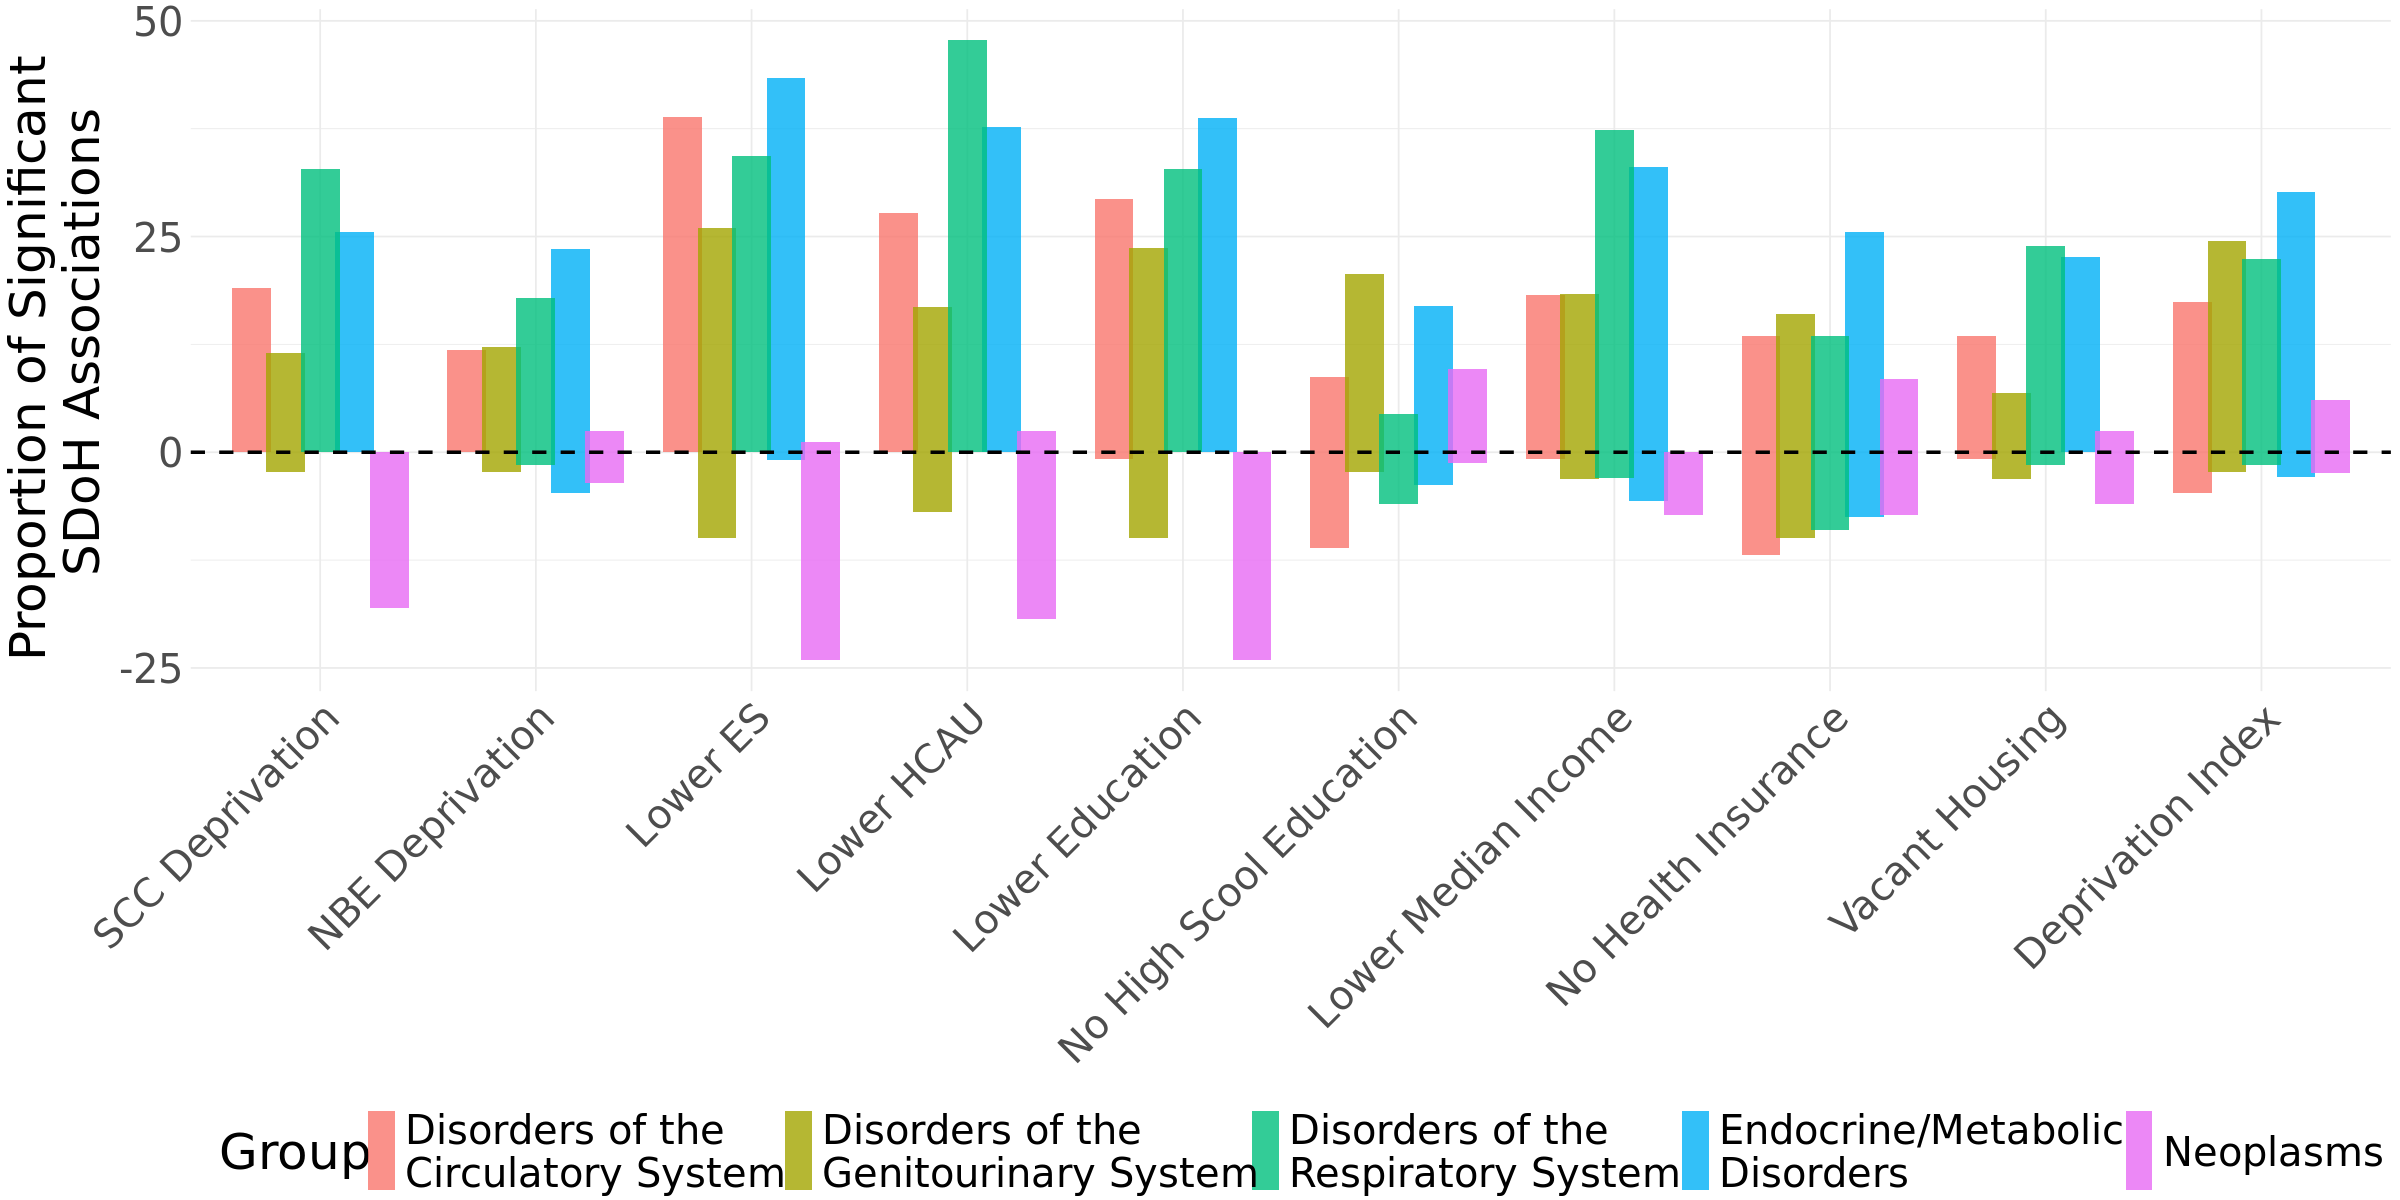

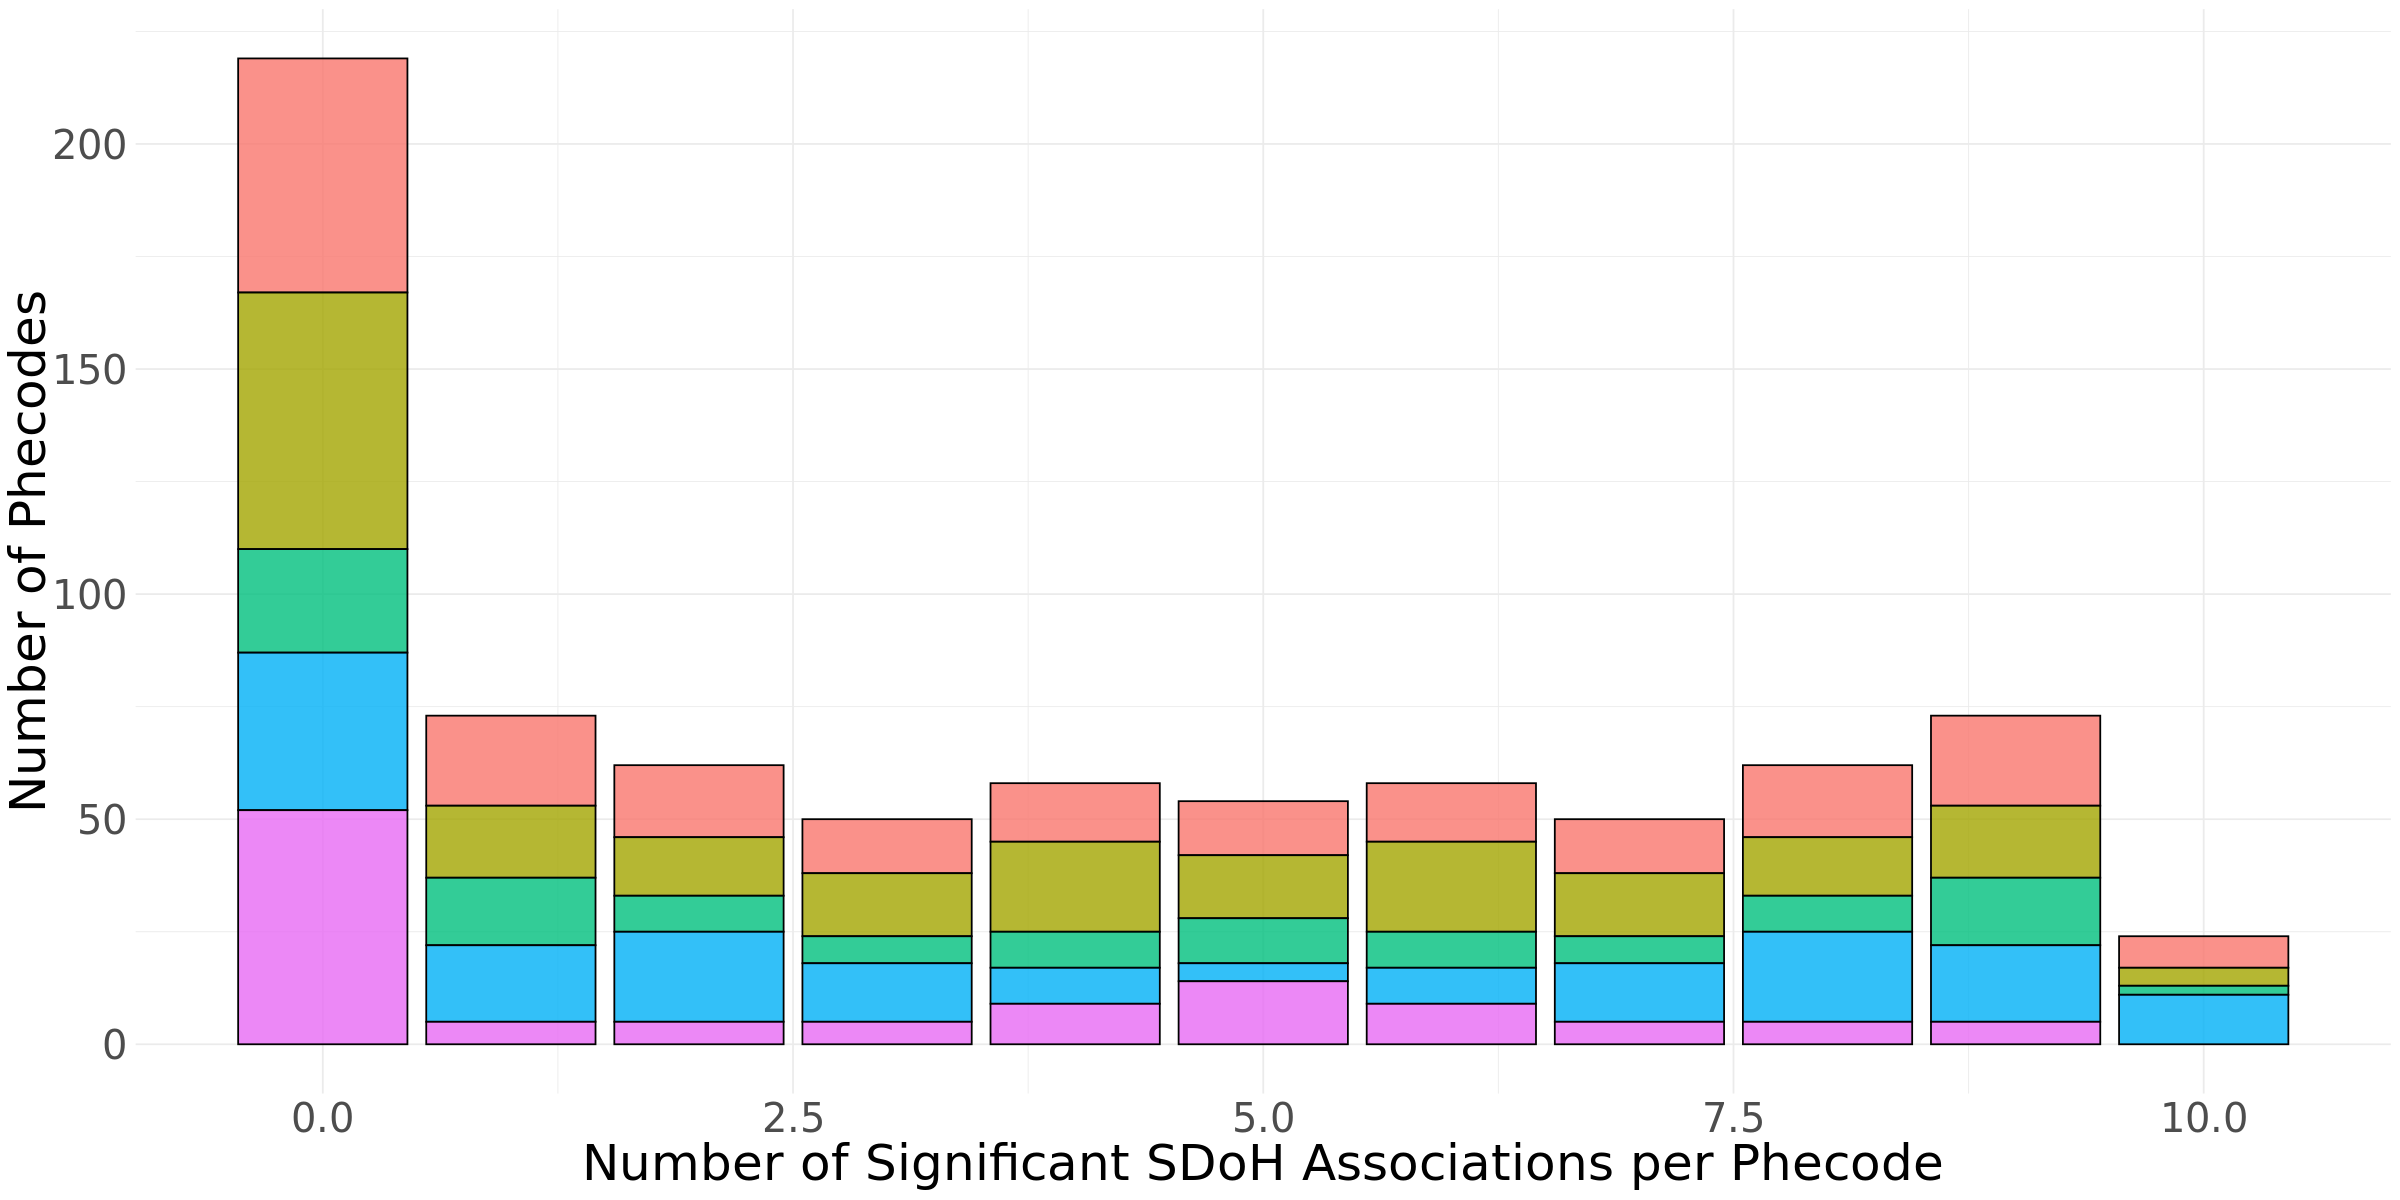

In [56]:
options(repr.plot.width = 20, repr.plot.height = 10)  # Set width and height

grapha<-ggplot(counts, aes(x = Domain_Label, y = proportion_sig_hits, fill = group)) +
  geom_col(position = position_dodge(width = 0.8), alpha = 0.8) +
  labs(
    x = " ",
    y = "Proportion of Significant \n SDoH Associations",
    fill = "Group"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", size = 1) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
      text = element_text(size = 30),
      legend.margin = margin(t = 0, b = 0),  
      legend.position = "bottom"
  )

ggsave("proportion_sig_sdoh_hits_per_domain.png", plot = grapha, width = 20, height = 10, dpi = 300)

combined_df$sig<-ifelse(combined_df$p_value<p_value_numeric, "YES", "NO")

# Count occurrences of each phecode within each group
counts_2 <- combined_df %>%
  group_by(group, phecode, sig) %>%
  summarise(n = n(), .groups = "drop")

counts_2$n <- ifelse(counts_2$sig == "NO" & counts_2$n == 10, 0, counts_2$n)

counts_2 <- counts_2 %>%
  mutate(
    group = disease_labels[group]
  )

# Plot a stacked histogram
graphb<-ggplot(counts_2, aes(x = n, fill = group)) +
  geom_bar(binwidth = 1, color = "black", alpha = 0.8, position = "stack") +
  labs(
    x = "Number of Significant SDoH Associations per Phecode",
    y = "Number of Phecodes",
    fill = "Group"
  ) +
  theme_minimal() +
  theme(text = element_text(size = 30),
       legend.position = "none")

ggsave("sig_sdoh_hits_per_phecode.png", plot = graphb, width = 20, height = 10, dpi = 300)


grapha
graphb

# Tables for Publication

In [57]:
combined_df <- combined_df %>%
  group_by(phecode) %>%
  mutate(number_of_associations = sum(p_value < p_value_numeric)) %>%
  ungroup()

combined_df

write_excel_csv(combined_df, "phewas_combined_results.csv")

system(paste0("gsutil cp ./phewas_combined_results.csv ", my_bucket, "/data/"), intern=T)



phecode,description,groupnum,group,color,cases,control,p_value,beta_ind,conf_int_1,conf_int_2,converged,code_val,neg_p_log_10,Domain,sig,number_of_associations
<dbl>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>
145.00,Cancer of mouth,2,neoplasms,darkcyan,182,46607,1.235438e-01,-0.9815759,-2.231,0.268,True,145.00,0.9081789,SCC,NO,0
145.20,Cancer of tongue,2,neoplasms,darkcyan,101,46607,3.644994e-01,-0.7707041,-2.436,0.895,True,145.20,0.4383032,SCC,NO,0
149.00,"Cancer of larynx, pharynx, nasal cavities",2,neoplasms,darkcyan,156,46607,1.515419e-02,-1.7303359,-3.127,-0.334,True,149.00,1.8194673,SCC,NO,0
153.00,Colorectal cancer,2,neoplasms,darkcyan,596,33609,4.240643e-01,0.2682681,-0.389,0.926,True,153.00,0.3725683,SCC,NO,0
153.20,Colon cancer,2,neoplasms,darkcyan,363,33609,7.332531e-02,-0.8095614,-1.696,0.076,True,153.20,1.1347461,SCC,NO,0
153.30,"Malignant neoplasm of rectum, rectosigmoid junction, and anus",2,neoplasms,darkcyan,324,33609,5.776809e-03,1.1835473,0.343,2.024,True,153.30,2.2383120,SCC,NO,0
158.00,Neoplasm of unspecified nature of digestive system,2,neoplasms,darkcyan,409,43028,5.511162e-01,0.2473362,-0.566,1.061,True,158.00,0.2587568,SCC,NO,2
159.00,Malignant neoplasm of other and ill-defined sites within the digestive organs and peritoneum,2,neoplasms,darkcyan,127,43028,3.625403e-02,-1.6715212,-3.236,-0.107,True,159.00,1.4406437,SCC,NO,0
165.00,Cancer within the respiratory system,2,neoplasms,darkcyan,451,46797,1.134038e-01,0.6234011,-0.148,1.395,True,165.00,0.9453724,SCC,NO,0


character(0)

# REDO WITH SES COHORT

In [58]:
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp gs://fc-secure-23df4c45-3a92-4e1e-ad2c-d7d6cdfab761/data/phewas_results_*", " ."), intern=T)

dfs<-c("income_SES_subset", "education_SES_subset", 
      "median_income_SES_subset", "high_school_education_SES_subset",  "no_health_insurance_SES_subset",
      "vacant_housing_SES_subset", "deprivation_index_SES_subset")

# Load and combine all files into one dataframe
combined_df <- map_dfr(dfs, function(domain) {
  file_path <- paste0("phewas_results_", domain, ".csv")
  if (file.exists(file_path)) {
    df <- read.csv(file_path) %>%
      mutate(Domain = domain)  # Append domain column
    return(df)
  } else {
    message("File not found: ", file_path)
    return(NULL)  # Skip if file doesn't exist
  }
})

# View combined dataframe
print(nrow(combined_df))
combined_df<-combined_df[combined_df$cases>=100, ]

combined_df<-combined_df[combined_df$group %in% c("circulatory system", "endocrine/metabolic",
                                              "genitourinary", "neoplasms", "respiratory" ), ]

combined_df<-combined_df[combined_df$converged=="True", ]
combined_df <- combined_df %>%
  group_by(phecode) %>%
  filter(n() == 7) %>%
  ungroup()

nrow(combined_df)
p_value_numeric<-.05/nrow(combined_df)
combined_df_sig<-combined_df[combined_df$p_value<p_value_numeric, ]
print(nrow(combined_df_sig))

#put in direction of risk
combined_df <- combined_df %>%
  mutate(
    beta_ind     = if_else(Domain %in% c("income_SES_subset", "education_SES_subset"), -beta_ind, beta_ind),
    conf_int_1   = if_else(Domain %in% c("income_SES_subset", "education_SES_subset"), -conf_int_1, conf_int_1),
    conf_int_2   = if_else(Domain %in% c("income_SES_subset", "education_SES_subset"), -conf_int_2, conf_int_2)
  )


head(combined_df)


character(0)

[1] 5096


[1] 4347

[1] 1701


phecode,description,groupnum,group,color,cases,control,p_value,beta_ind,conf_int_1,conf_int_2,converged,code_val,neg_p_log_10,Domain
<dbl>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
145.0,Cancer of mouth,2,neoplasms,darkcyan,358,101118,0.0865521686,-0.4569939,0.066,-0.980,True,145.0,1.0627220,income_SES_subset
145.2,Cancer of tongue,2,neoplasms,darkcyan,190,101118,0.0321304029,-0.7609171,-0.065,-1.457,True,145.2,1.4930838,income_SES_subset
149.0,"Cancer of larynx, pharynx, nasal cavities",2,neoplasms,darkcyan,365,101118,0.1871515187,0.3750522,0.932,-0.182,True,149.0,0.7278066,income_SES_subset
149.1,Cancer of oropharynx,2,neoplasms,darkcyan,199,101118,0.5267062439,-0.2288280,0.480,-0.937,True,149.1,0.2784315,income_SES_subset
149.4,Cancer of larynx,2,neoplasms,darkcyan,105,101118,0.0000051728,3.2245397,4.611,1.838,True,149.4,5.2862743,income_SES_subset
150.0,Cancer of esophagus,2,neoplasms,darkcyan,143,93502,0.4551829552,0.3385286,1.227,-0.550,True,150.0,0.3418140,income_SES_subset


In [60]:
length(unique(combined_df$phecode))
length(unique(combined_df$phecode))*7

[1] 621

[1] 4347

In [61]:
length(unique(combined_df_sig$phecode)) / length(unique(combined_df$phecode)) *100

combined_df_sig %>%
  distinct(group, phecode) %>%
  group_by(group) %>%
  summarise(sig_count = n()) %>%
  left_join(
    combined_df %>%
      distinct(group, phecode) %>%
      group_by(group) %>%
      summarise(total_count = n()),
    by = "group"
  ) %>%
  mutate(percent_sig = round((sig_count / total_count) * 100, 2))

[1] 67.79388

group,sig_count,total_count,percent_sig
<chr>,<int>,<int>,<dbl>
circulatory system,106,151,70.20
endocrine/metabolic,94,129,72.87
genitourinary,109,154,70.78
neoplasms,46,108,42.59
respiratory,66,79,83.54


In [62]:
# Count occurrences of each phecode within each group within each sdoh
counts <- combined_df_sig %>%
  group_by(group, Domain) %>%
  summarise(n = n(), .groups = "drop")

In [63]:
total_counts <- combined_df %>%
  group_by(group) %>%
  summarise(total = length(unique(phecode)), .groups = "drop")

counts<-merge(counts, total_counts, on="group", how="left")
counts$proportion_sig_hits<-counts$n / counts$total *100

In [64]:
domain_labels <- c(
  "education_SES_subset" = "Lower Education",       
  "vacant_housing_SES_subset" = "Vacant Housing",
  "median_income_SES_subset" = "Lower Median Income",
  "no_health_insurance_SES_subset" = "No Health Insurance",
  "high_school_education_SES_subset" = "No High Scool Education",
  "deprivation_index_SES_subset" = "Deprivation Index",
  "income_SES_subset" = "Lower Percent of \n Poverty Threshold"
)


custom_colors <- c(
  "education_SES_subset" = "darkblue",       
  "vacant_housing_SES_subset" = "grey",
  "area_poverty_SES_subset" = "grey",
  "median_income_SES_subset" = "grey",
  "assited_income_SES_subset" = "grey",
  "no_health_insurance_SES_subset" = "grey",
  "high_school_education_SES_subset" = "grey",
  "assisted_income_SES_subset" = "grey",
  "deprivation_index_SES_subset" = "grey",
  "income_SES_subset" = "green"
)

disease_labels <- c(
"circulatory system" = "Disorders of the\nCirculatory System   ", 
"endocrine/metabolic" = "Endocrine/Metabolic   \nDisorders",
"genitourinary" = "Disorders of the\nGenitourinary System   ",
"neoplasms" = "Neoplasms",
"respiratory" = "Disorders of the\nRespiratory System   "
)

counts <- counts %>%
  mutate(
    Domain_Label = domain_labels[Domain],  # map names
    Domain_Color = custom_colors[Domain], 
    group = disease_labels[group]
  )

In [65]:
# Create a signed version of proportion_sig_hits
counts <- combined_df %>%
  mutate(direction = ifelse(beta_ind > 0, "positive", "negative")) %>%
  
  # Count unique phecodes per Domain + group
  group_by(Domain, group) %>%
  mutate(total_hits = n_distinct(phecode)) %>%
  ungroup() %>%
  
  #Filter to statistically significant hits
  filter(p_value<p_value_numeric)|>

  # Count positive and negative significant hits
  group_by(Domain, group, direction) %>%
  summarise(n = n(), total_hits = unique(total_hits), .groups = "drop") |>
  mutate(proportion_sig_hits = n/total_hits*100)

counts <- counts %>%
  mutate(
    Domain_Label = domain_labels[Domain],  # map names
    Domain_Color = custom_colors[Domain], 
    group = disease_labels[group],
    proportion_sig_hits = ifelse(direction=="negative", -proportion_sig_hits, proportion_sig_hits)
  )

counts$Domain_Label <- factor(counts$Domain_Label, 
                levels = c("Lower Percent of \n Poverty Threshold", "Lower Education",
                           "No High Scool Education", "Lower Median Income",
                          "No Health Insurance", "Vacant Housing",  "Deprivation Index"))


Warning message in geom_bar(binwidth = 1, color = "black", alpha = 0.8, position = "stack"):
“Ignoring unknown parameters: `binwidth`”


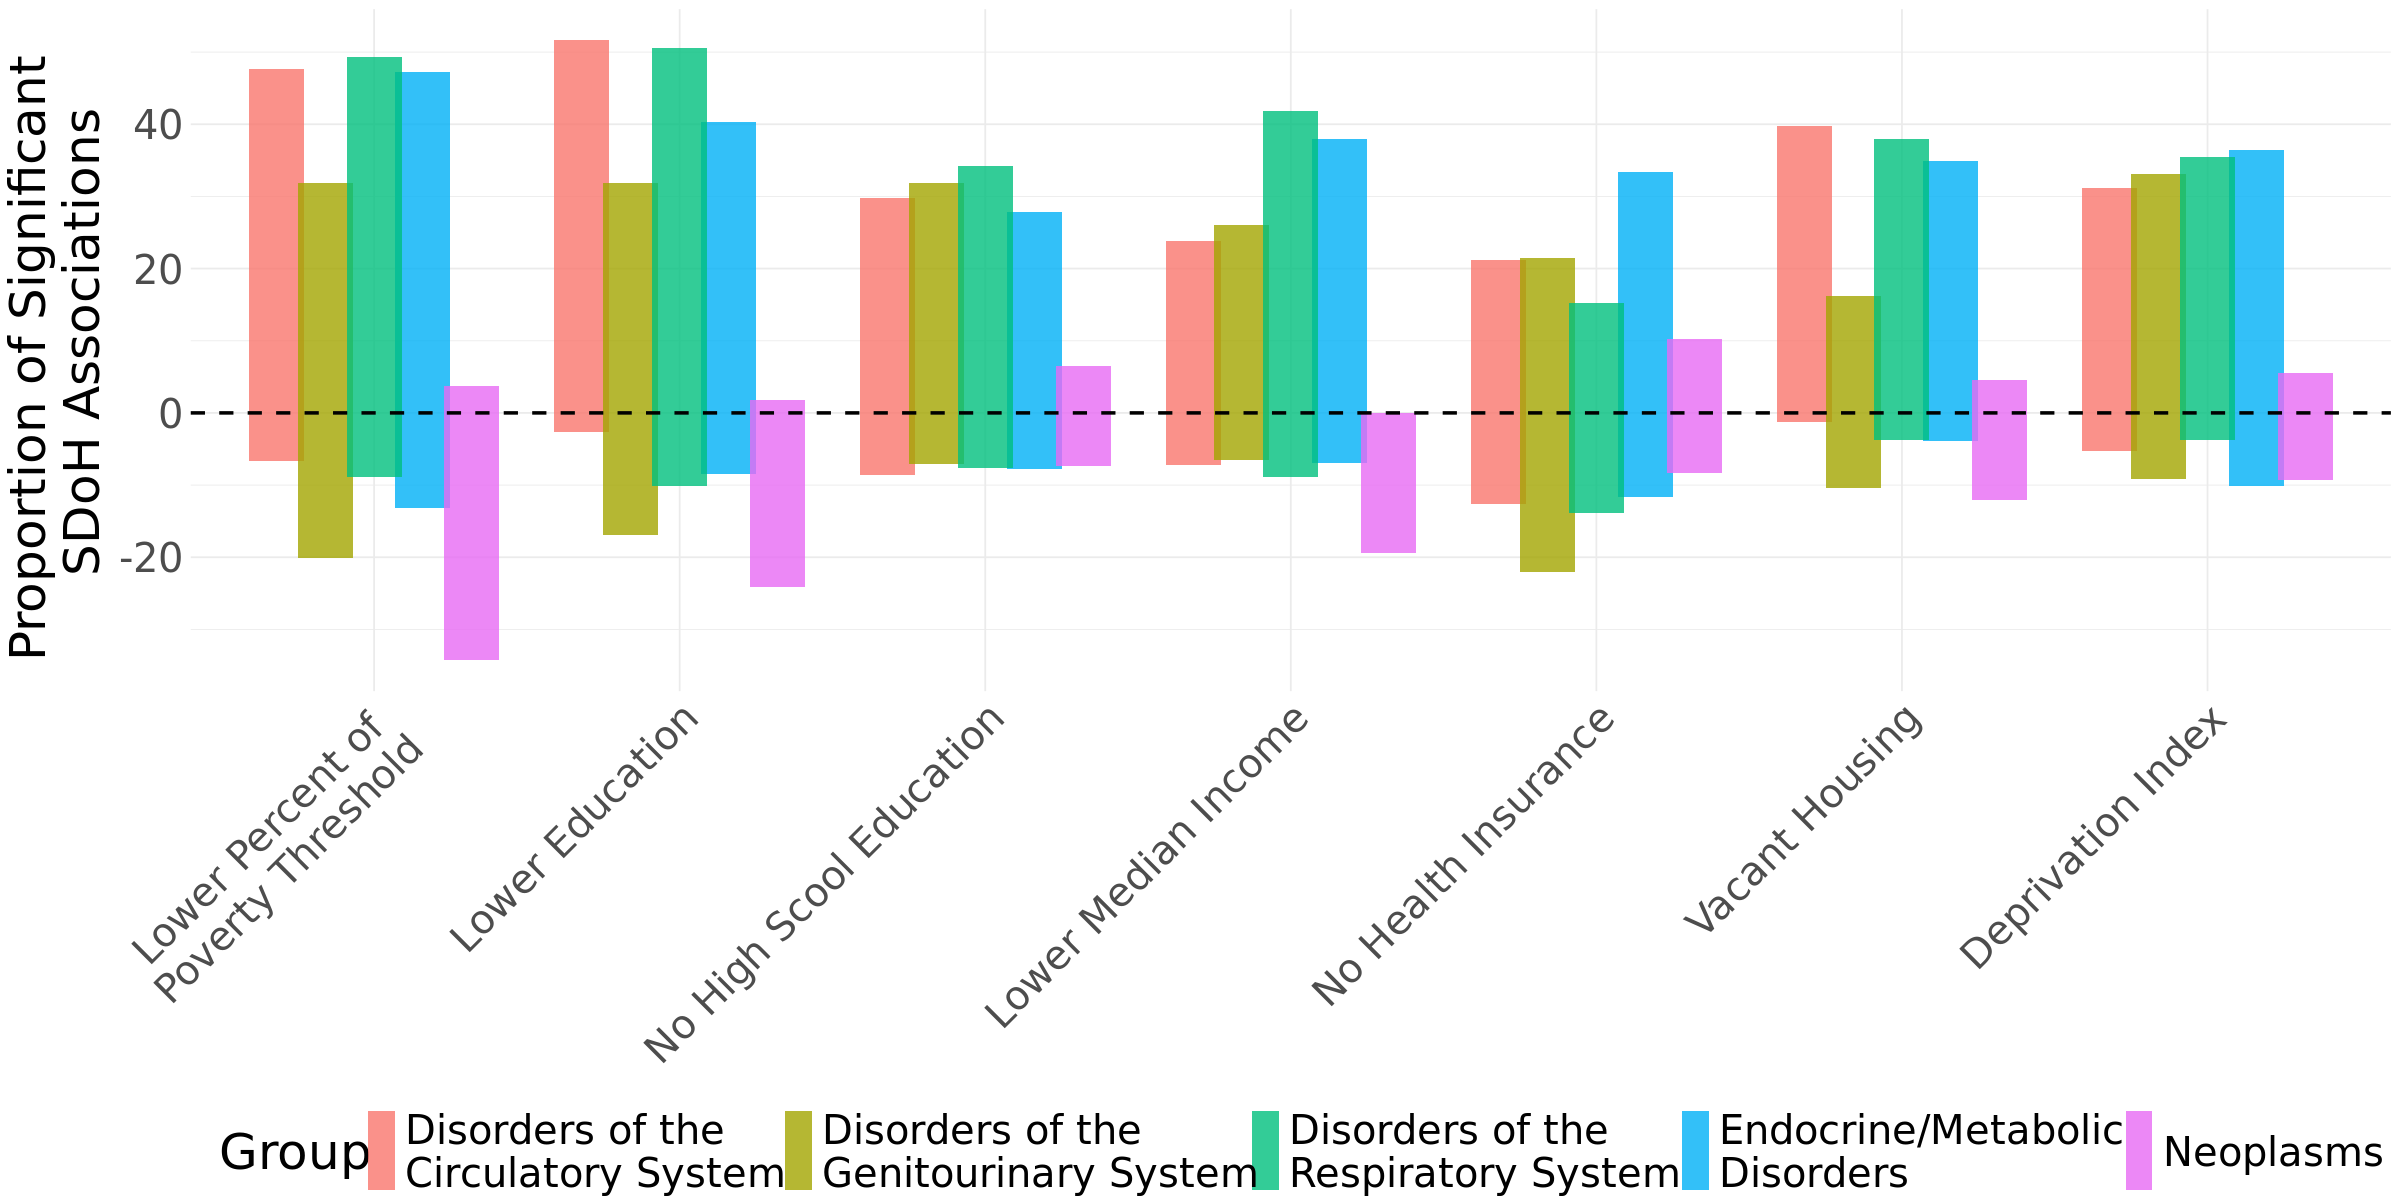

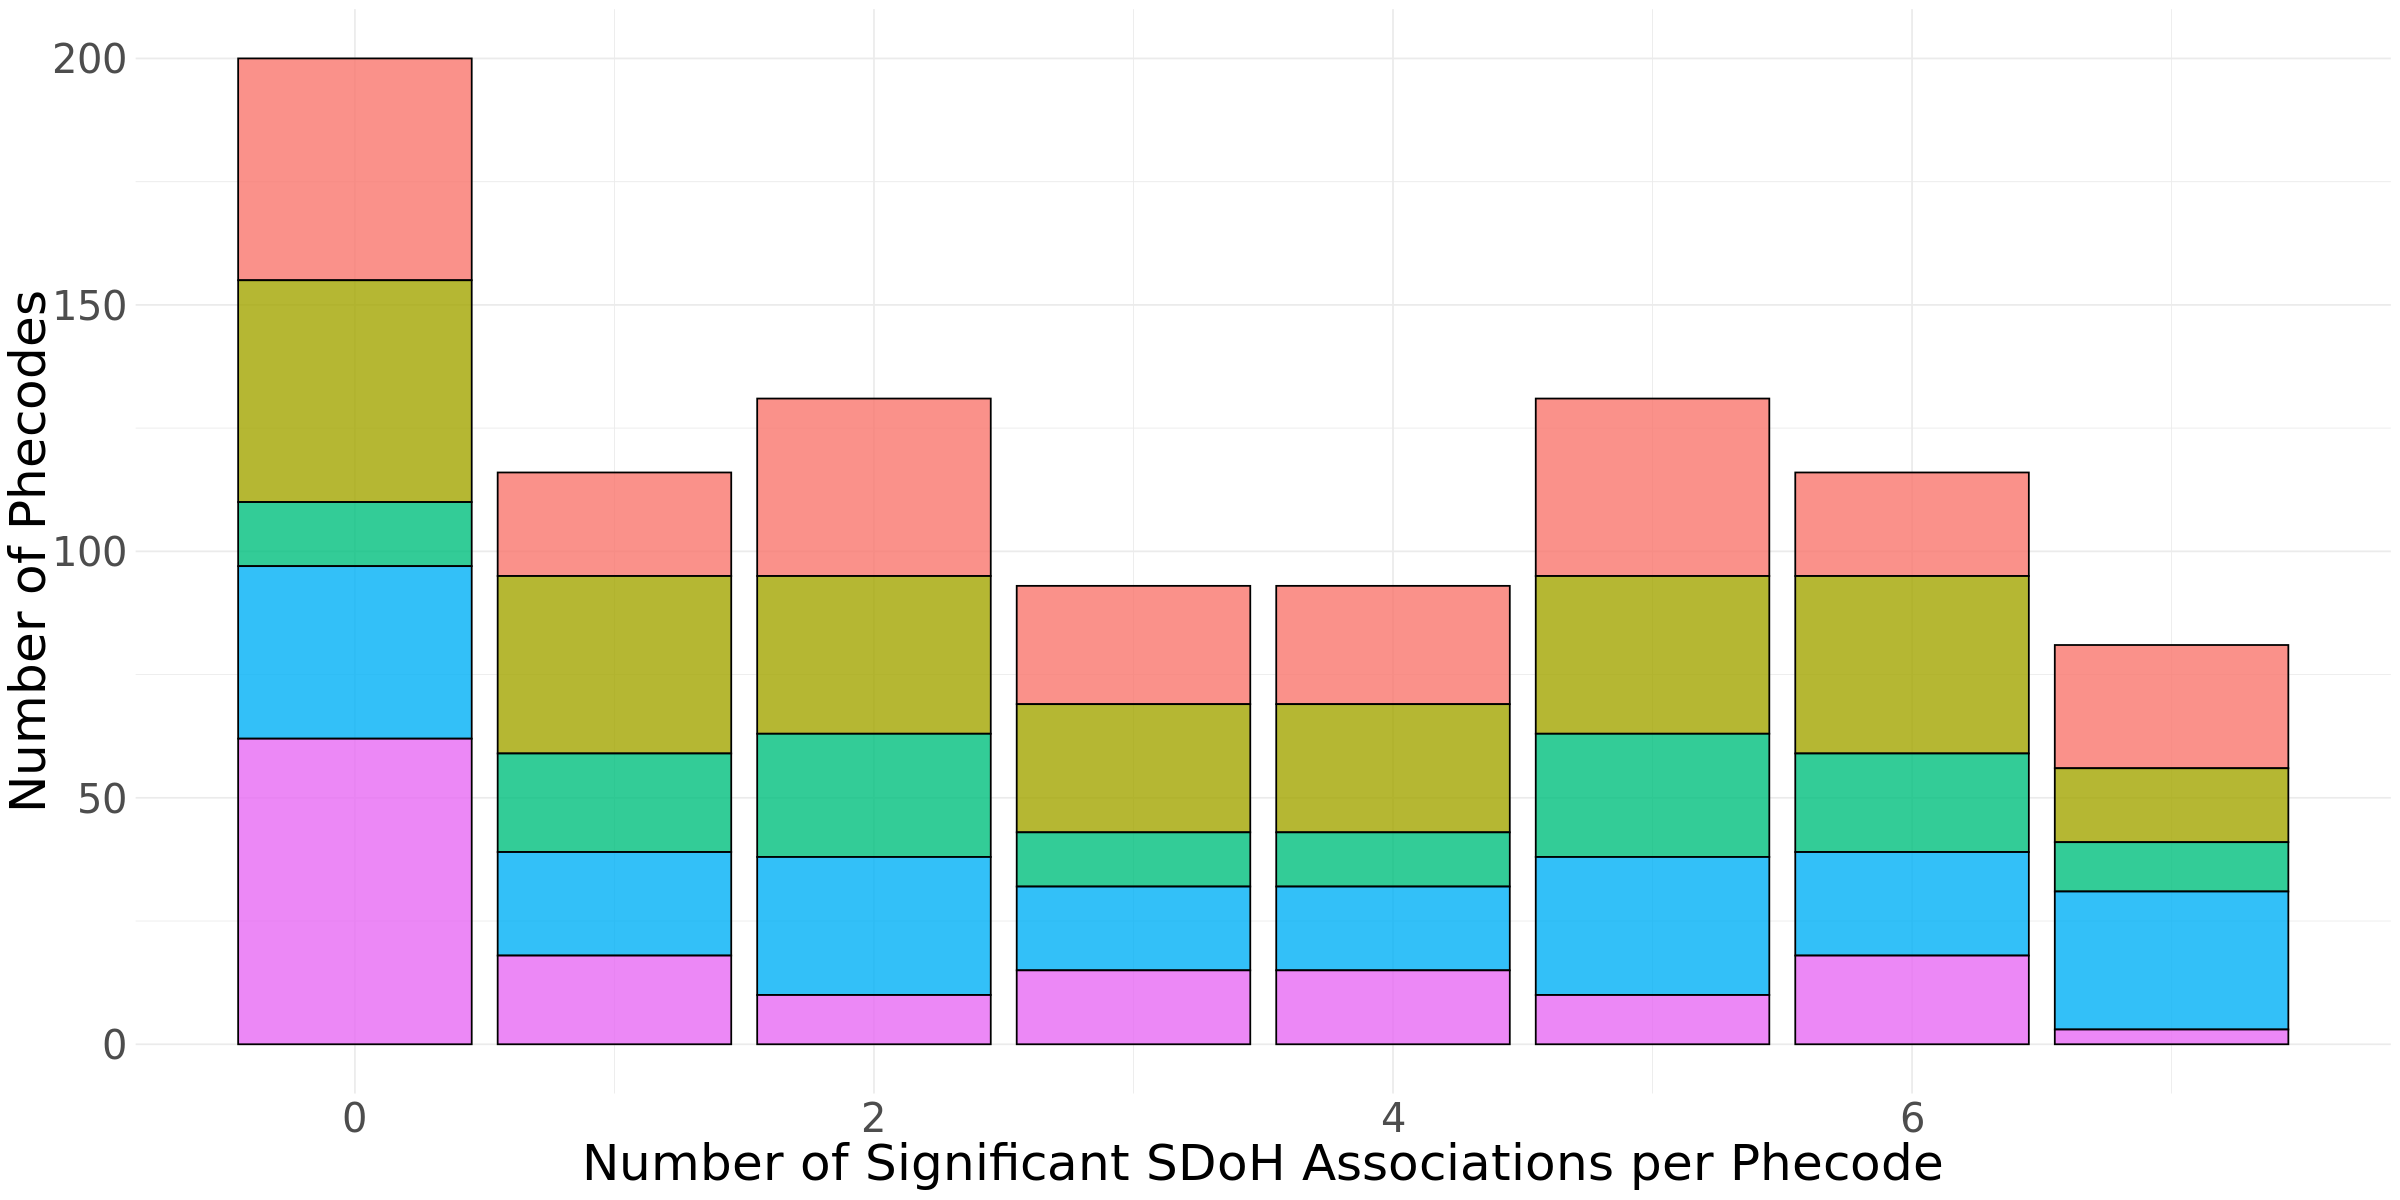

In [66]:
options(repr.plot.width = 20, repr.plot.height = 10)  # Set width and height

grapha<-ggplot(counts, aes(x = Domain_Label, y = proportion_sig_hits, fill = group)) +
  geom_col(position = position_dodge(width = 0.8), alpha = 0.8) +
  labs(
    x = " ",
    y = "Proportion of Significant \n SDoH Associations",
    fill = "Group"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", size = 1) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
      text = element_text(size = 30),
      legend.margin = margin(t = 0, b = 0),  
      legend.position = "bottom"
  )

ggsave("proportion_sig_sdoh_hits_per_domain.png", plot = grapha, width = 20, height = 10, dpi = 300)

combined_df$sig<-ifelse(combined_df$p_value<p_value_numeric, "YES", "NO")

# Count occurrences of each phecode within each group
counts_2 <- combined_df %>%
  group_by(group, phecode, sig) %>%
  summarise(n = n(), .groups = "drop")

counts_2$n <- ifelse(counts_2$sig == "NO" & counts_2$n == 7, 0, counts_2$n)

counts_2 <- counts_2 %>%
  mutate(
    group = disease_labels[group]
  )

# Plot a stacked histogram
graphb<-ggplot(counts_2, aes(x = n, fill = group)) +
  geom_bar(binwidth = 1, color = "black", alpha = 0.8, position = "stack") +
  labs(
    x = "Number of Significant SDoH Associations per Phecode",
    y = "Number of Phecodes",
    fill = "Group"
  ) +
  theme_minimal() +
  theme(text = element_text(size = 30),
       legend.position = "none")

ggsave("sig_sdoh_hits_per_phecode.png", plot = graphb, width = 20, height = 10, dpi = 300)


grapha
graphb

In [67]:
combined_df <- combined_df %>%
  group_by(phecode) %>%
  mutate(number_of_associations = sum(p_value < p_value_numeric)) %>%
  ungroup()

combined_df

write_excel_csv(combined_df, "phewas_combined_results_SES.csv")

system(paste0("gsutil cp ./phewas_combined_results_SES.csv ", my_bucket, "/data/"), intern=T)


phecode,description,groupnum,group,color,cases,control,p_value,beta_ind,conf_int_1,conf_int_2,converged,code_val,neg_p_log_10,Domain,sig,number_of_associations
<dbl>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>
145.00,Cancer of mouth,2,neoplasms,darkcyan,358,101118,8.655217e-02,-0.45699391,0.066,-0.980,True,145.00,1.06272205,income_SES_subset,NO,0
145.20,Cancer of tongue,2,neoplasms,darkcyan,190,101118,3.213040e-02,-0.76091708,-0.065,-1.457,True,145.20,1.49308383,income_SES_subset,NO,0
149.00,"Cancer of larynx, pharynx, nasal cavities",2,neoplasms,darkcyan,365,101118,1.871515e-01,0.37505216,0.932,-0.182,True,149.00,0.72780664,income_SES_subset,NO,0
149.10,Cancer of oropharynx,2,neoplasms,darkcyan,199,101118,5.267062e-01,-0.22882803,0.480,-0.937,True,149.10,0.27843153,income_SES_subset,NO,0
149.40,Cancer of larynx,2,neoplasms,darkcyan,105,101118,5.172800e-06,3.22453966,4.611,1.838,True,149.40,5.28627430,income_SES_subset,YES,1
150.00,Cancer of esophagus,2,neoplasms,darkcyan,143,93502,4.551830e-01,0.33852864,1.227,-0.550,True,150.00,0.34181401,income_SES_subset,NO,0
151.00,Cancer of stomach,2,neoplasms,darkcyan,155,93502,2.336321e-01,0.53396501,1.413,-0.345,True,151.00,0.63146754,income_SES_subset,NO,0
153.00,Colorectal cancer,2,neoplasms,darkcyan,1374,75793,2.940789e-03,0.45466774,0.754,0.155,True,153.00,2.53153609,income_SES_subset,NO,0
153.20,Colon cancer,2,neoplasms,darkcyan,854,75793,9.164304e-01,0.01935994,0.381,-0.342,True,153.20,0.03790052,income_SES_subset,NO,0


character(0)